<a href="https://colab.research.google.com/github/sagark2006/ModelClassificationPipeline/blob/main/Predictive_Classification_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing the important libraries that are needed for this project**


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

**Loading the dataset from Scikit-learn (Breast Cancer Dataset)**


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (569, 30)
Target Shape: (569,)


In [ ]:
df = pd.DataFrame(X, columns=data.feature_names)

df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 455
Testing Samples: 114


Decision Tree --->>>


In [ ]:
tree = DecisionTreeClassifier(max_depth=4)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

tree_acc = accuracy_score(
    y_test,
    tree_pred
)

print("Decision Tree Accuracy:", tree_acc)

Decision Tree Accuracy: 0.9298245614035088


Logistic Regreassion --->>>

In [ ]:
logistic = LogisticRegression(
    max_iter=5000
)

logistic.fit(
    X_train,
    y_train
)

logistic_pred = logistic.predict(
    X_test
)

logistic_acc = accuracy_score(
    y_test,
    logistic_pred
)

print(
    "Logistic Regression Accuracy:",
    logistic_acc
)

Logistic Regression Accuracy: 0.956140350877193


SVM

In [ ]:
svm = SVC(
    kernel='rbf',
    probability=True,
    C=10
)

svm.fit(
    X_train,
    y_train
)

svm_pred = svm.predict(
    X_test
)

svm_acc = accuracy_score(
    y_test,
    svm_pred
)

print(
    "SVM Accuracy:",
    svm_acc
)

SVM Accuracy: 0.9473684210526315


**Using confusion Matrix to get detailed insights instead of accuracy only**

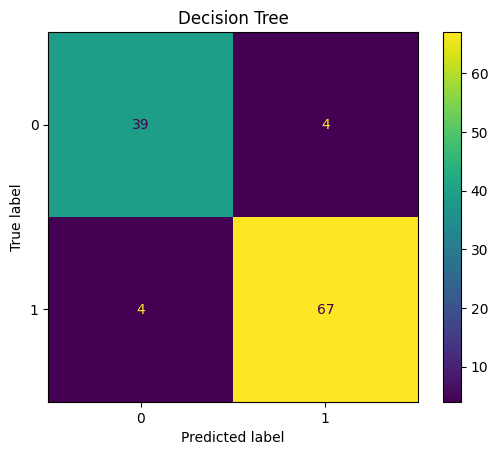

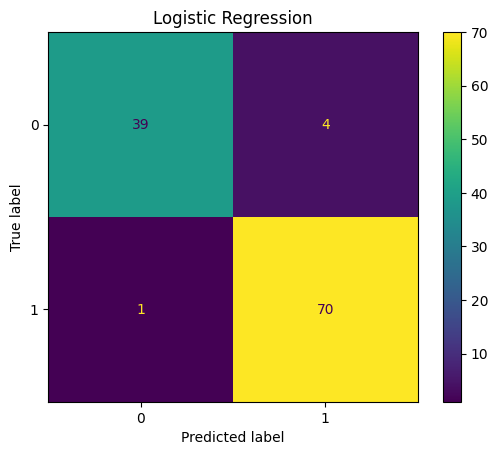

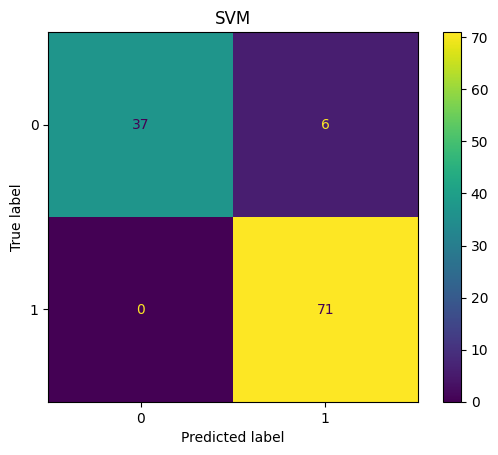

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Decision Tree": tree,
    "Logistic Regression": logistic,
    "SVM": svm
}

for name, model in models.items():

    pred = model.predict(X_test)

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot()

    plt.title(name)

    plt.show()

**AUC and ROC curve to measure model's ability to distinguish between classes.**

Decision Tree AUC = 0.907
Logistic Regression AUC = 0.998
SVM AUC = 0.998


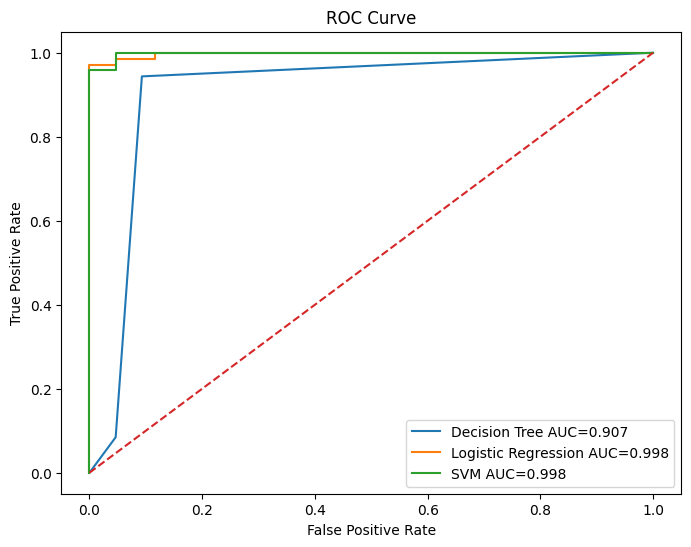

In [ ]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    probs = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probs
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    print(
        f"{name} AUC = {roc_auc:.3f}"
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={roc_auc:.3f}"
    )

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

Feature Importance


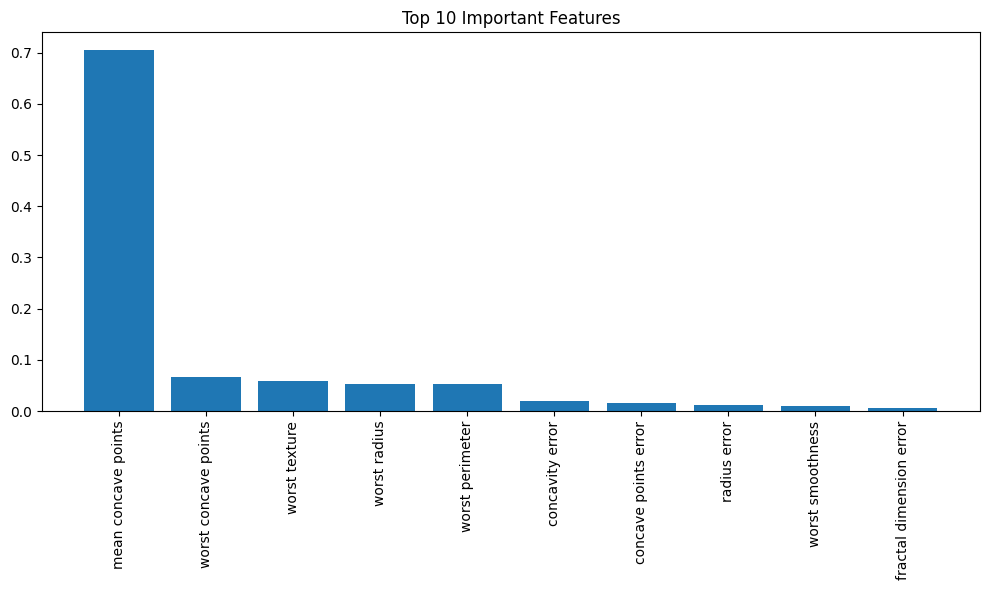

In [ ]:
importance = tree.feature_importances_

indices = np.argsort(
    importance
)[::-1][:10]

plt.figure(figsize=(10,6))

plt.bar(
    range(len(indices)),
    importance[indices]
)

plt.xticks(
    range(len(indices)),
    [data.feature_names[i] for i in indices],
    rotation=90
)

plt.title(
    "Top 10 Important Features"
)

plt.tight_layout()

plt.show()

Accuracy Comparison Chart

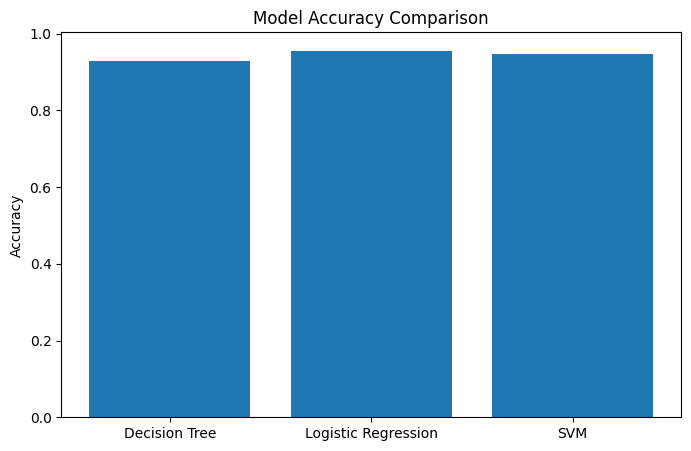

In [ ]:
accuracies = {
    "Decision Tree": tree_acc,
    "Logistic Regression": logistic_acc,
    "SVM": svm_acc
}

plt.figure(figsize=(8,5))

plt.bar(
    accuracies.keys(),
    accuracies.values()
)

plt.ylabel("Accuracy")

plt.title(
    "Model Accuracy Comparison"
)

plt.show()